<a href="https://colab.research.google.com/github/Jorge-UC3M/Machin-Learnin-P2/blob/main/Cuaderno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 2: Determinación de tipos de estrellas
## **Alumnos:**
*   María Arias Rodríguez, 100522272
*   Jorge Ignacio Castañeda Vallenilla, 100522273

## **Link a github:** https://github.com/maria-env

## <u>**Parte 0: Preparación centralizada**</u>

In [ ]:
!pip install hdbscan
from hdbscan.validity import validity_index  # Función DBCV

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage

SEED = 100522272
np.random.seed(SEED)

## <u>**Parte 1: Codificación**</u>

Antes de empezar con la codificación, vamos a ver un pequeño fragmento de los datos.

In [ ]:
# Cargar datos
df = pd.read_csv('stars_data.csv')
print('Forma del dataset:', df.shape)
print()
df.head(10)

Forma del dataset: (240, 6)



,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,Red,M
1,3042,0.000500,0.1542,16.60,Red,M
2,2600,0.000300,0.1020,18.70,Red,M
3,2800,0.000200,0.1600,16.65,Red,M
4,1939,0.000138,0.1030,20.06,Red,M
5,2840,0.000650,0.1100,16.98,Red,M
6,2637,0.000730,0.1270,17.22,Red,M
7,2600,0.000400,0.0960,17.40,Red,M
8,2650,0.000690,0.1100,17.45,Red,M
9,2700,0.000180,0.1300,16.05,Red,M


También, vamos a sacar un par de estadísticas para obtener un resumen de lo que hay en el excel.

In [ ]:
print('Información del dataset:')
print(df.info())
print()
print('Estadísticas descriptivas:')
df.describe()

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    object 
 5   Spectral_Class  240 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 11.4+ KB
None

Estadísticas descriptivas:


,Temperature,L,R,A_M
count,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396
std,9552.425037,179432.244940,517.155763,10.532512
min,1939.000000,0.000080,0.008400,-11.920000
25%,3344.250000,0.000865,0.102750,-6.232500
50%,5776.000000,0.070500,0.762500,8.313000
75%,15055.500000,198050.000000,42.750000,13.697500
max,40000.000000,849420.000000,1948.500000,20.060000


Antes de meter los datos en los modelos de clustering, necesitamos limpiarlos. Los datos de texto como Color o Spectral_Class suelen venir con espacios extra o diferencias de mayúsculas que pueden confundir al algoritmo. Además, estas variables no son categorías cualquiera, el color y el tipo espectral siguen un orden lógico según la temperatura de la estrella. Por eso, en lugar de usar números al azar, las vamos a ordenar de más fría a más caliente para que la distancia numérica tenga un sentido físico real.

In [ ]:
df['Color'] = df['Color'].str.lower().str.strip()
df['Spectral_Class'] = df['Spectral_Class'].str.strip()

print('Valores únicos de Color (normalizados):')
print(sorted(df['Color'].unique()))
print()
print('Distribución de Color:')
print(df['Color'].value_counts())
print()
print('Valores únicos de Spectral_Class:')
print(sorted(df['Spectral_Class'].unique()))
print()
print('Distribución de Spectral_Class:')
print(df['Spectral_Class'].value_counts())

Valores únicos de Color (normalizados):
['blue', 'blue white', 'blue-white', 'orange', 'orange-red', 'pale yellow orange', 'red', 'white', 'white-yellow', 'whitish', 'yellow-white', 'yellowish', 'yellowish white']

Distribución de Color:
Color
red                   112
blue                   56
blue-white             27
blue white             14
white                  10
yellow-white            8
yellowish white         3
yellowish               3
whitish                 2
orange                  2
pale yellow orange      1
white-yellow            1
orange-red              1
Name: count, dtype: int64

Valores únicos de Spectral_Class:
['A', 'B', 'F', 'G', 'K', 'M', 'O']

Distribución de Spectral_Class:
Spectral_Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64


Una vez hecho estos pasos previos, ahora vamos a comenzar con la codificación. Tanto el color como la clase espectral están relacionados con la temperatura de la estrella. Codificamos estas variables de forma ordinal:

- **Color**: de más frío (rojo) a más caliente (azul), siguiendo el espectro electromagnético visible.
- **Spectral_Class**: la secuencia O > B > A > F > G > K > M va de más caliente a más fría. Codificamos de M=0 (más fría) a O=6 (más caliente).

In [ ]:
color_order = [
    'red',
    'orange-red',
    'orange',
    'pale yellow orange',
    'yellowish',
    'yellow-white',
    'white-yellow',
    'yellowish white',
    'whitish',
    'white',
    'blue white',
    'blue-white',
    'blue',
]

# Codificación ordinal de Spectral_Class
spectral_order = ['M', 'K', 'G', 'F', 'A', 'B', 'O']

# Se envuelve la lista de orden en otra lista, ya que OrdinalEncoder espera una
# lista de categorías para cada característica
encoder_color = OrdinalEncoder(categories=[color_order])
encoder_spectral = OrdinalEncoder(categories=[spectral_order])

df['Color_encoded'] = encoder_color.fit_transform(df[['Color']])
df['Spectral_Class_encoded'] = encoder_spectral.fit_transform(df[['Spectral_Class']])

print('Codificación de Color:')
color_map = df[['Color', 'Color_encoded']].drop_duplicates().sort_values('Color_encoded')
print(color_map.to_string(index=False))
print()
print('Codificación de Spectral_Class:')
spectral_map = df[['Spectral_Class', 'Spectral_Class_encoded']].drop_duplicates().sort_values('Spectral_Class_encoded')
print(spectral_map.to_string(index=False))

Codificación de Color:
             Color  Color_encoded
               red            0.0
        orange-red            1.0
            orange            2.0
pale yellow orange            3.0
         yellowish            4.0
      yellow-white            5.0
      white-yellow            6.0
   yellowish white            7.0
           whitish            8.0
             white            9.0
        blue white           10.0
        blue-white           11.0
              blue           12.0

Codificación de Spectral_Class:
Spectral_Class  Spectral_Class_encoded
             M                     0.0
             K                     1.0
             G                     2.0
             F                     3.0
             A                     4.0
             B                     5.0
             O                     6.0


A continuación, preparamos la matriz de features:

In [ ]:
feature_cols = ['Temperature', 'L', 'R', 'A_M', 'Color_encoded', 'Spectral_Class_encoded']
X = df[feature_cols].values

print(f"Matriz de features: {X.shape}")
df[feature_cols].head()

Matriz de features: (240, 6)


,Temperature,L,R,A_M,Color_encoded,Spectral_Class_encoded
0,3068,0.002400,0.1700,16.12,0.0,0.0
1,3042,0.000500,0.1542,16.60,0.0,0.0
2,2600,0.000300,0.1020,18.70,0.0,0.0
3,2800,0.000200,0.1600,16.65,0.0,0.0
4,1939,0.000138,0.1030,20.06,0.0,0.0


## <u>**Parte 2: Reducción de dimensionalidad con PCA**</u>

En este apartado nos toca utilizar la técninca de PCA, sin embargo, antes de hacerlo necesitamos escalar los datos.

In [ ]:
pipeline_full = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(random_state=SEED))
])

X_pca_full = pipeline_full.fit_transform(X)
pca_full = pipeline_full.named_steps['pca']

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print('Varianza explicada por componente:')
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f'  PC{i+1}: {ev:.4f} ({ev:.2%}) | Acumulada: {cv:.2%}')

Varianza explicada por componente:
  PC1: 0.5571 (55.71%) | Acumulada: 55.71%
  PC2: 0.2954 (29.54%) | Acumulada: 85.25%
  PC3: 0.0638 (6.38%) | Acumulada: 91.64%
  PC4: 0.0475 (4.75%) | Acumulada: 96.38%
  PC5: 0.0337 (3.37%) | Acumulada: 99.76%
  PC6: 0.0024 (0.24%) | Acumulada: 100.00%


Una vez escalados, podremos ver nuestro dataset en un gráfico de dos ejes y entender mejor cómo se agrupan las estrellas.

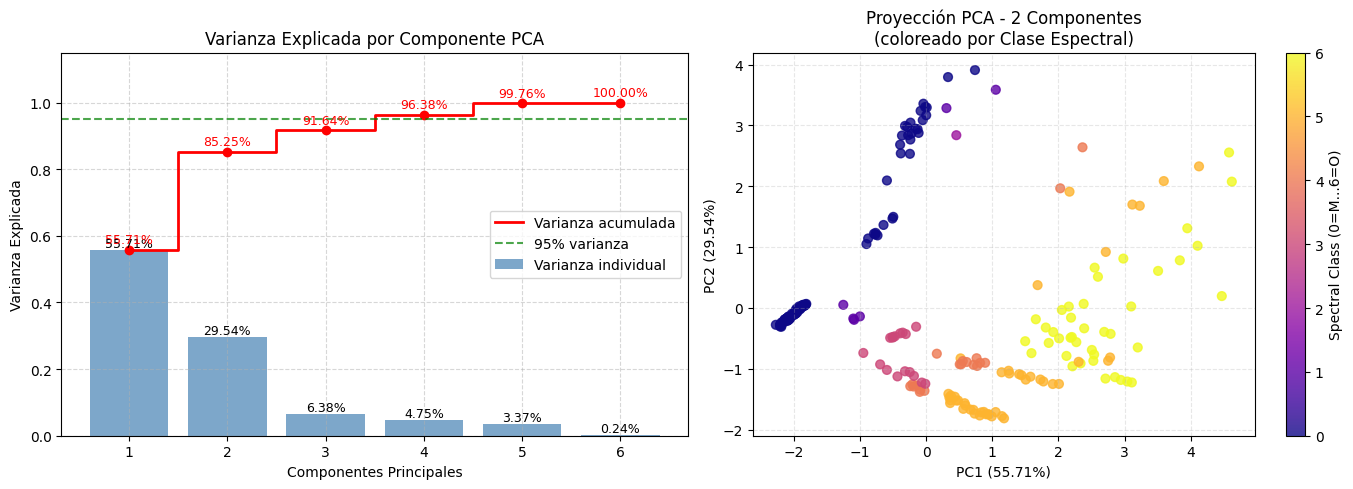


Con 2 componentes principales se explica el 85.25% de la varianza total.


In [ ]:
# Visualizar varianza explicada acumulada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de varianza individual y acumulada
ax = axes[0]
bars = ax.bar(range(1, len(explained_variance) + 1), explained_variance,
              alpha=0.7, color='steelblue', label='Varianza individual')
ax.step(range(1, len(cumulative_variance) + 1), cumulative_variance,
        where='mid', color='red', linewidth=2, label='Varianza acumulada')
ax.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
        'ro', markersize=6)

for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance)):
    ax.text(i + 1, ev + 0.01, f'{ev:.2%}', ha='center', fontsize=9)
    ax.text(i + 1, cv + 0.02, f'{cv:.2%}', ha='center', fontsize=9, color='red')

ax.axhline(y=0.95, color='green', linestyle='--', alpha=0.7, label='95% varianza')
ax.set_xlabel('Componentes Principales')
ax.set_ylabel('Varianza Explicada')
ax.set_title('Varianza Explicada por Componente PCA')
ax.legend(loc='center right')
ax.set_ylim(0, 1.15)
ax.set_xticks(range(1, len(explained_variance) + 1))
ax.grid(True, linestyle='--', alpha=0.5)

# Proyección en las 2 primeras componentes
ax2 = axes[1]
scatter = ax2.scatter(X_pca_full[:, 0], X_pca_full[:, 1],
                      c=df['Spectral_Class_encoded'], cmap='plasma',
                      s=40, alpha=0.8)
plt.colorbar(scatter, ax=ax2, label='Spectral Class (0=M...6=O)')
ax2.set_xlabel(f'PC1 ({explained_variance[0]:.2%})')
ax2.set_ylabel(f'PC2 ({explained_variance[1]:.2%})')
ax2.set_title('Proyección PCA - 2 Componentes\n(coloreado por Clase Espectral)')
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nCon 2 componentes principales se explica el {cumulative_variance[1]:.2%} de la varianza total.')

Como podemos ver en el resultado, pasar de 6 a 2 componentes es una buena idea porque de esta forma explicamos una gran parte de la varianza total. Es por esto que a continuación realizaremos el PCA de cos componentes.

In [ ]:
pipeline_2d = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=SEED))
])

X_2d = pipeline_2d.fit_transform(X)
pca_2d = pipeline_2d.named_steps['pca']

print('Datos reducidos a 2 componentes principales:')
print(f'  Shape original: {X.shape}')
print(f'  Shape reducida: {X_2d.shape}')
print(f'  Varianza total explicada: {pca_2d.explained_variance_ratio_.sum():.2%}')

Datos reducidos a 2 componentes principales:
  Shape original: (240, 6)
  Shape reducida: (240, 2)
  Varianza total explicada: 85.25%


## <u>**Parte 3: Algoritmos de clustering**</u>

###<u>Algoritmo K-Means</u>

Empezamos con K-Means, que es el algoritmo más clásico para hacer grupos. El reto aquí es saber cuántos grupos (k) elegir. Para no hacerlo a ojo, usamos el "método del codo" y Silhouette Score. Buscamos ese punto donde añadir más grupos ya no mejora mucho la precisión.

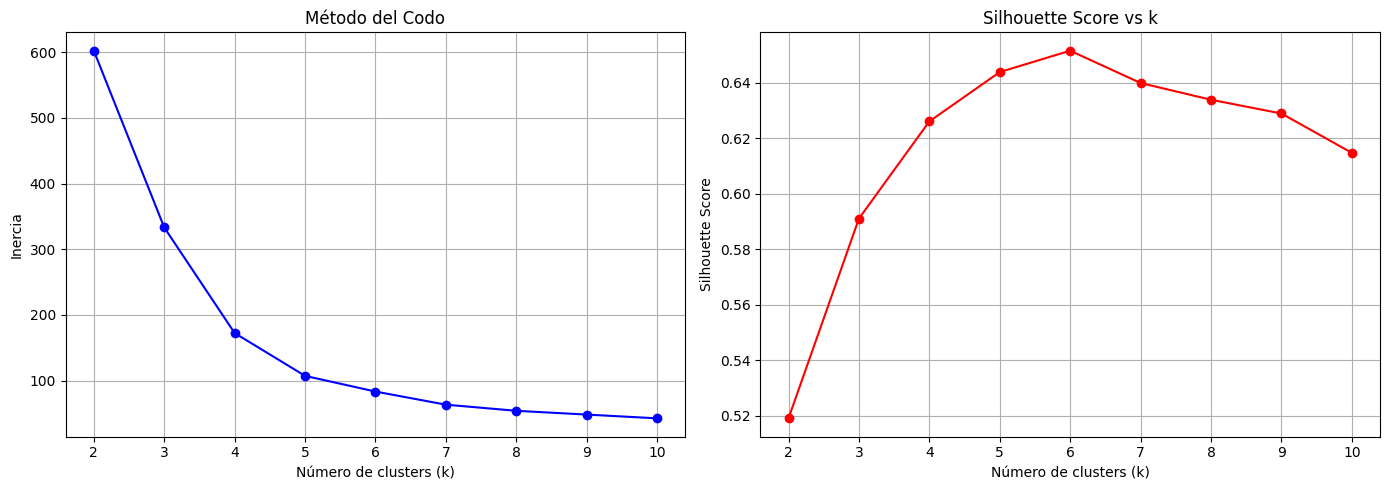


Resultados K-Means:
k    | Inercia      | Silhouette Score
----------------------------------------
2    | 602.25       | 0.5191
3    | 333.21       | 0.5911
4    | 172.48       | 0.6261
5    | 107.34       | 0.6439
6    | 83.46        | 0.6516
7    | 63.48        | 0.6400
8    | 54.17        | 0.6339
9    | 48.41        | 0.6290
10   | 42.69        | 0.6148


In [ ]:
K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_2d)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_2d, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del Codo')
ax1.grid(True)

ax2.plot(K_range, sil_scores, 'ro-')
ax2.set_xlabel('Número de clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs k')
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nResultados K-Means:")
print(f"{'k':<4} | {'Inercia':<12} | {'Silhouette Score'}")
print("-" * 40)
for k, iner, sil in zip(K_range, inertias, sil_scores):
    print(f"{k:<4} | {iner:<12.2f} | {sil:.4f}")

Para elegir el número óptimo de grupos (estrellas), hemos analizado dos métricas clave: la Inercia y el Silhouette Score.  

*   Inercia (Método del Codo): Esta métrica mide qué tan compactos son los grupos. Como vemos en los datos, la inercia baja drásticamente al principio, pero a partir de k=6 la caída se vuelve mucho más lenta y suave. Esto indica que añadir más grupos a partir de ahí no aporta una mejora significativa en la estructura del modelo.

*   Silhouette Score: Esta es la métrica de "calidad" de los grupos. Mide qué tan bien separadas están las estrellas de un cluster frente a los demás. En nuestra tabla, el valor más alto (el pico de la gráfica) se alcanza precisamente en k=6 con un valor de 0.6516. A partir de este punto, el score empieza a bajar, lo que significa que los grupos empiezan a solaparse y a ser menos claros.  

Conclusión: Ambos métodos coinciden en que k=6 es la mejor elección para este modelo. Con esta configuración, conseguimos grupos que son internamente muy compactos y que están bien diferenciados entre sí.


Mejor k según Silhouette Score: 6


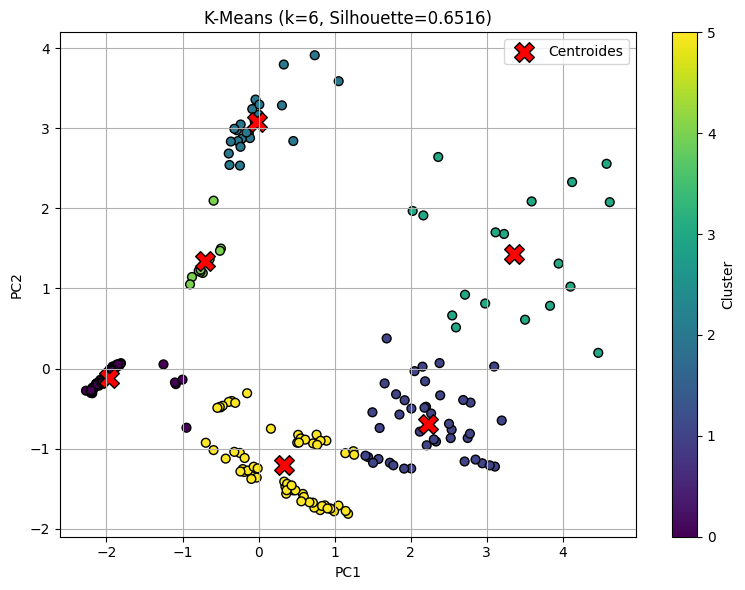

In [ ]:
best_k = list(K_range)[np.argmax(sil_scores)]
print(f"\nMejor k según Silhouette Score: {best_k}")

kmeans_best = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
kmeans_labels = kmeans_best.fit_predict(X_2d)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_labels,
                      cmap='viridis', s=40, edgecolors='black')
centroids = kmeans_best.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X',
            s=200, edgecolors='black', label='Centroides')
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
sil_km = silhouette_score(X_2d, kmeans_labels)
plt.title(f'K-Means (k={best_k}, Silhouette={sil_km:.4f})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

En este gráfico vemos cómo el algoritmo ha agrupado las estrellas tras reducir los datos a dos dimensiones principales (PC1 y PC2).  

*   Los colores: Representan los 6 tipos de estrellas identificados. Al estar bien separados, sabemos que el modelo diferencia correctamente las categorías.

*   Las "X" rojas (Centroides): Son el punto central de cada grupo, representan las características medias de cada tipo de estrella.

*   Calidad del modelo: El valor de Silhouette (0.6516) confirma que los grupos son sólidos y que las estrellas dentro de cada color se parecen mucho entre sí, estando bien alejadas de los otros grupos.

En resumen, el algoritmo ha logrado separar los datos en familias coherentes que coinciden con la clasificación astronómica real.

###<u>Algoritmo Hierarchical Clustering / Dendrogramas</u>

Probamos distintas funciones de linkage (ward, complete, average, single),
evaluamos con Silhouette Score y seleccionamos la mejor combinación.

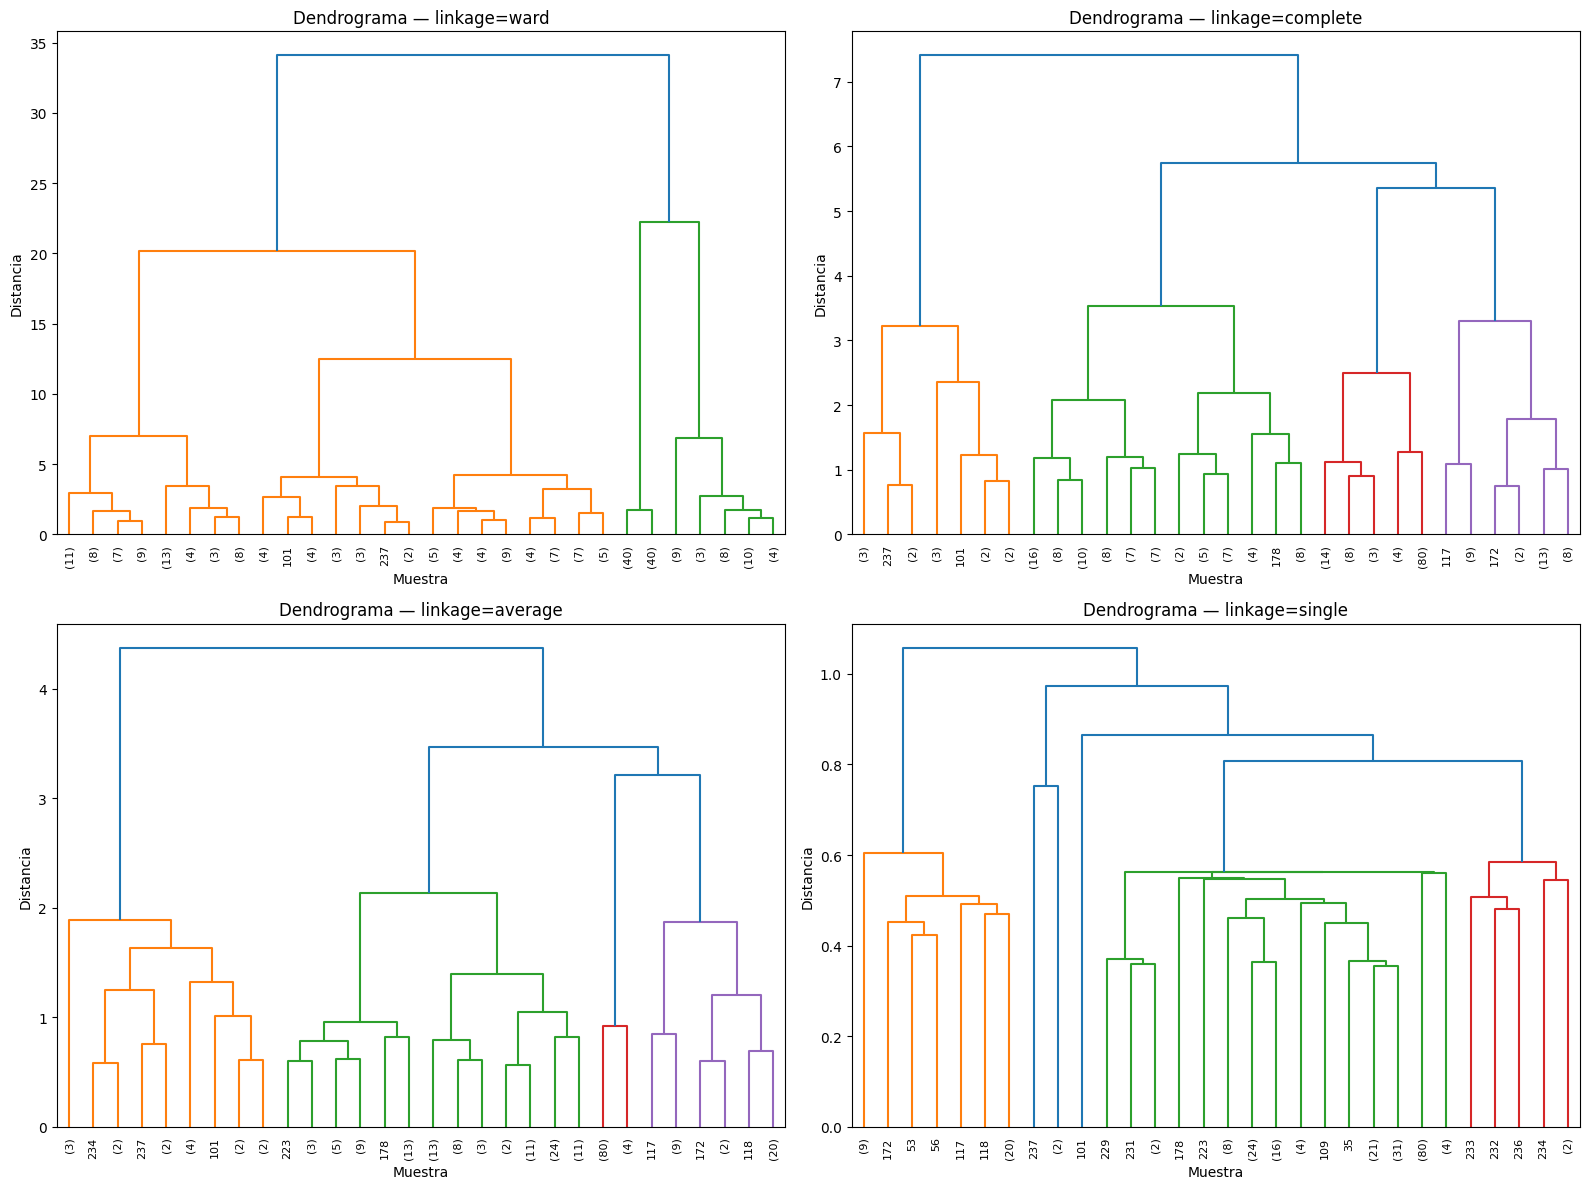

In [ ]:
linkage_methods = ['ward', 'complete', 'average', 'single']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, method in zip(axes.flatten(), linkage_methods):
    Z = linkage(X_2d, method=method)
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
               leaf_rotation=90, leaf_font_size=8)
    ax.set_title(f'Dendrograma — linkage={method}')
    ax.set_xlabel('Muestra')
    ax.set_ylabel('Distancia')

plt.tight_layout()
plt.show()

En esta sección utilizamos Dendrogramas para ver cómo se agrupan las estrellas de forma jerárquica, probando cuatro métodos distintos de enlace (linkage):  

*   Ward (El más equilibrado): Es el gráfico que mejor separa las estrellas en grupos claros y del mismo tamaño. Al minimizar la varianza dentro de cada grupo, nos permite ver con mucha facilidad dónde están las familias principales de estrellas.

*   Complete: Agrupa las estrellas fijándose en los miembros más lejanos. Aunque separa bien los grupos grandes, a veces crea divisiones un poco forzadas.  

*   Average: Busca un punto medio usando la distancia promedio entre estrellas. Es un método estable, pero los grupos no aparecen tan definidos como en el de Ward.

*   Single: Es el que peor funciona para este caso. Al agrupar por los puntos más cercanos, crea un efecto de "escalera" que no permite distinguir bien los tipos de estrellas.

In [ ]:
print(f"{'Linkage':<10} | {'k':<3} | {'Silhouette Score'}")
print("-" * 40)

best_hc_score = -1
best_hc_link = None
best_hc_k = 0

for method in linkage_methods:
    for n_clust in range(2, 11):
        agg = AgglomerativeClustering(n_clusters=n_clust, linkage=method)
        labels_agg = agg.fit_predict(X_2d)
        score = silhouette_score(X_2d, labels_agg)
        print(f"{method:<10} | {n_clust:<3} | {score:.4f}")
        if score > best_hc_score:
            best_hc_score = score
            best_hc_link = method
            best_hc_k = n_clust

print(f"\nMejor combinación: linkage={best_hc_link}, k={best_hc_k}, "
      f"Silhouette={best_hc_score:.4f}")

Linkage    | k   | Silhouette Score
----------------------------------------
ward       | 2   | 0.4939
ward       | 3   | 0.5632
ward       | 4   | 0.6056
ward       | 5   | 0.6275
ward       | 6   | 0.6105
ward       | 7   | 0.6276
ward       | 8   | 0.5995
ward       | 9   | 0.5947
ward       | 10  | 0.5844
complete   | 2   | 0.3971
complete   | 3   | 0.4774
complete   | 4   | 0.5812
complete   | 5   | 0.5334
complete   | 6   | 0.5046
complete   | 7   | 0.5015
complete   | 8   | 0.5800
complete   | 9   | 0.5849
complete   | 10  | 0.5737
average    | 2   | 0.3866
average    | 3   | 0.5024
average    | 4   | 0.6095
average    | 5   | 0.6235
average    | 6   | 0.6152
average    | 7   | 0.6208
average    | 8   | 0.6223
average    | 9   | 0.6218
average    | 10  | 0.6153
single     | 2   | 0.3718
single     | 3   | 0.2818
single     | 4   | 0.2526
single     | 5   | 0.2975
single     | 6   | 0.2823
single     | 7   | 0.0966
single     | 8   | 0.1014
single     | 9   | 0.1355
single     | 

Tras comparar los cuatro resultados, el método de Ward con k=7 es el más adecuado para nuestra investigación, ya que es el que mejor refleja la estructura natural y organizada de los datos.

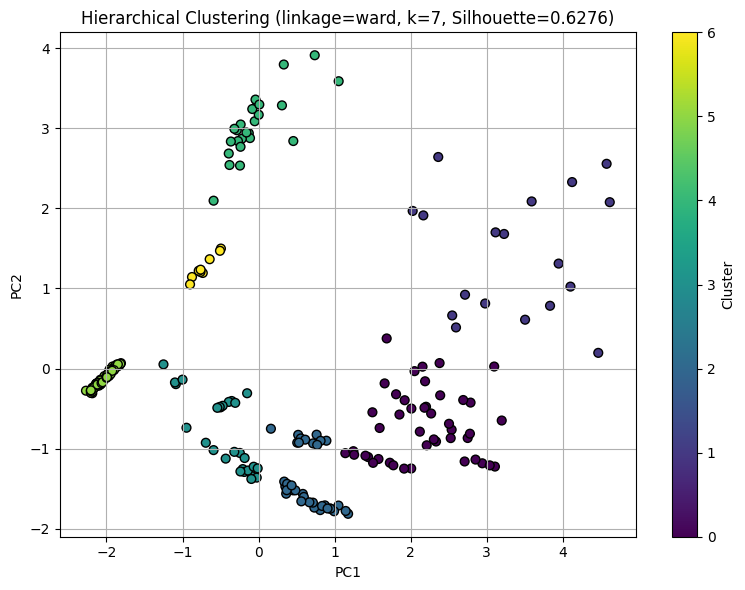

In [ ]:
agg_best = AgglomerativeClustering(n_clusters=best_hc_k, linkage=best_hc_link)
agg_labels = agg_best.fit_predict(X_2d)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=agg_labels,
                      cmap='viridis', s=40, edgecolors='black')
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Hierarchical Clustering (linkage={best_hc_link}, k={best_hc_k}, '
          f'Silhouette={best_hc_score:.4f})')
plt.grid(True)
plt.tight_layout()
plt.show()

###<u>Algoritmo DBSCAN</u>

Para DBSCAN, primero usamos la heurística del gráfico k-distance para
estimar un buen valor de epsilon, y luego realizamos una búsqueda
de hiperparámetros evaluando con la métrica DBCV.

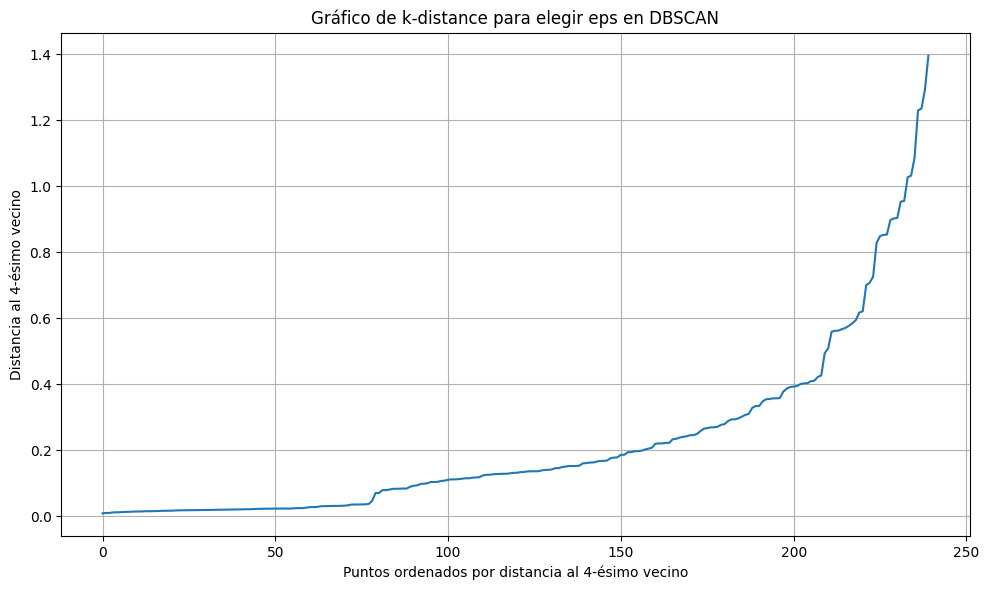

In [ ]:
# Gráfico k-distance para estimar epsilon
min_samples_default = 5

nn = NearestNeighbors(n_neighbors=min_samples_default)
nn.fit(X_2d)
distances, _ = nn.kneighbors(X_2d)
sorted_distances = np.sort(distances[:, min_samples_default - 1])

plt.figure(figsize=(10, 6))
plt.plot(sorted_distances)
plt.xlabel(f'Puntos ordenados por distancia al {min_samples_default-1}-ésimo vecino')
plt.ylabel(f'Distancia al {min_samples_default-1}-ésimo vecino')
plt.title('Gráfico de k-distance para elegir eps en DBSCAN')
plt.grid(True)
plt.tight_layout()
plt.show()

A continuación, identificamos la zona del codo para elegir epsilons candidatos. Tomamos un rango de valores alrededor del codo observado y ajustamos según la escala de los datos PCA

In [ ]:
p90 = int(len(sorted_distances) * 0.90)
eps_codo = sorted_distances[p90]
print(f"Epsilon estimado (percentil 90 del k-distance): {eps_codo:.4f}")

eps_values = np.round(np.arange(
    max(0.1, eps_codo - 0.5),
    eps_codo + 1.0,
    0.1
), 2)
min_samples_values = [3, 4, 5, 6, 7]

print(f"\nValores de epsilon a probar: {eps_values}")
print(f"Valores de min_samples a probar: {min_samples_values}")

Epsilon estimado (percentil 90 del k-distance): 0.5773

Valores de epsilon a probar: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5]
Valores de min_samples a probar: [3, 4, 5, 6, 7]


In [ ]:
# Búsqueda de hiperparámetros con DBCV
print(f"\n{'MS':<4} | {'EPS':<6} | {'Clusters':<9} | {'% Ruido':<8} | {'DBCV Score'}")
print("-" * 55)

best_dbcv = -np.inf
best_eps = 0
best_ms = 0
best_db_labels = None

for ms in min_samples_values:
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=ms).fit(X_2d)
        labels_db = db.labels_
        n_clusters = len(set(labels_db) - {-1})
        n_noise = list(labels_db).count(-1)
        perc_noise = (n_noise / len(labels_db)) * 100

        if n_clusters > 1:
            score = validity_index(X_2d.astype(np.float64), labels_db)
            print(f"{ms:<4} | {eps:<6.2f} | {n_clusters:<9} | {perc_noise:>6.1f}% | {score:.4f}")
            if score > best_dbcv:
                best_dbcv = score
                best_eps = eps
                best_ms = ms
                best_db_labels = labels_db.copy()
        else:
            print(f"{ms:<4} | {eps:<6.2f} | {n_clusters:<9} | {perc_noise:>6.1f}% | N/A")

print(f"\nMejor configuración: epsilon={best_eps:.2f}, min_samples={best_ms}, "
      f"DBCV={best_dbcv:.4f}")


MS   | EPS    | Clusters  | % Ruido  | DBCV Score
-------------------------------------------------------
3    | 0.10   | 13        |   36.2% | 0.4622
3    | 0.20   | 13        |   16.2% | 0.6293
3    | 0.30   | 9         |   13.3% | 0.5991
3    | 0.40   | 9         |    7.5% | 0.5088
3    | 0.50   | 8         |    5.0% | 0.3459
3    | 0.60   | 4         |    1.7% | 0.3474
3    | 0.70   | 3         |    1.7% | 0.3809
3    | 0.80   | 4         |    0.4% | 0.3788
3    | 0.90   | 3         |    0.0% | -0.4150
3    | 1.00   | 2         |    0.0% | -0.4229
3    | 1.10   | 1         |    0.0% | N/A
3    | 1.20   | 1         |    0.0% | N/A
3    | 1.30   | 1         |    0.0% | N/A
3    | 1.40   | 1         |    0.0% | N/A
3    | 1.50   | 1         |    0.0% | N/A
4    | 0.10   | 11        |   41.2% | 0.4514
4    | 0.20   | 11        |   21.2% | 0.6236
4    | 0.30   | 9         |   13.3% | 0.5991
4    | 0.40   | 7         |   10.8% | 0.4862
4    | 0.50   | 6         |    7.9% | 0.3330
4    |

Creamos el gráfico para visualizar mejor el resultado, aunque ya vemos que la mejor configuración que ha salido es con epsilon=0.20 y min_samples=3.

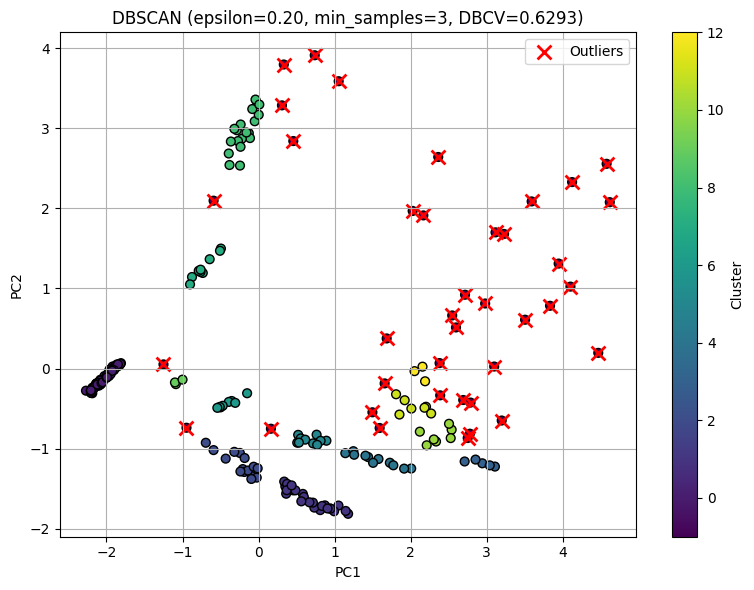

Nº de clusters: 13
Nº de outliers: 39


In [ ]:
# Visualización del mejor DBSCAN
dbscan_labels = best_db_labels

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=dbscan_labels,
                     cmap='viridis', s=40, edgecolors='black')
# Marcar outliers
mask_noise = dbscan_labels == -1
ax.scatter(X_2d[mask_noise, 0], X_2d[mask_noise, 1],
           c='red', marker='x', s=100, linewidths=2, label='Outliers')
plt.colorbar(scatter, label='Cluster')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

n_clusters_db = len(set(dbscan_labels) - {-1})
n_noise_db = np.sum(mask_noise)
ax.set_title(f'DBSCAN (epsilon={best_eps:.2f}, min_samples={best_ms}, '
             f'DBCV={best_dbcv:.4f})')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

print(f'Nº de clusters: {n_clusters_db}')
print(f'Nº de outliers: {n_noise_db}')

En esta gráfica observamos cómo funciona un algoritmo basado en densidad en lugar de distancias fijas:

* Los Outliers (Cruces Rojas): DBSCAN ha identificado 39 estrellas como ruido o valores atípicos. Son puntos que están demasiado aislados para formar parte de una familia estelar densa.

* Número de Clusters (13): A diferencia de K-Means, aquí no le dijimos al algoritmo que buscara 6 grupos, él mismo ha encontrado 13 islas de densidad. Esto indica que dentro de las categorías principales de estrellas, hay subgrupos con características muy específicas.

* DBCV = 0.6293: Al ser mayor a 0.5, significa que el agrupamiento es de alta calidad. Indica que las estrellas dentro de cada color están muy juntas (alta densidad) y que hay un vacío claro entre los distintos grupos (buena separación).

DBSCAN nos ofrece una visión más detallada que K-Means. Mientras que K-Means obliga a cada estrella a pertenecer a un grupo, DBSCAN es más realista: agrupa solo lo que claramente se parece y marca el resto como outliers, lo cual es muy útil para detectar estrellas con comportamientos físicos inusuales.

## <u>**Parte 4: Comparación de algoritmos de clustering**</u>

Para comparar bien los diferentes algoritmos, primero vamos a hacer un breve resumen de cada uno:

* K-Means es un algoritmo basado en centroides que asume clusters esféricos
de tamaño similar. Funciona bien cuando los clusters están bien separados.

* Hierarchical Clustering construye una jerarquía de clusters. La elección
de la función de linkage influye mucho en los resultados. Ward minimiza
la varianza intra-cluster y suele funcionar bien con clusters compactos.

* DBSCAN es un algoritmo basado en densidad que puede detectar clusters
de forma arbitraria y manejar outliers. Es especialmente útil cuando
los datos tienen ruido o clusters de densidades diferentes.

In [ ]:
print("=== RESUMEN DE RESULTADOS ===\n")

# Algoritmos con Silhouette
print("Algoritmos con Silhouette Score (comparable entre sí):")
print(f"{'Algoritmo':<25} | {'Silhouette Score':<16} | {'Clusters'}")
print("-" * 55)
print(f"{'K-Means':<25} | {sil_km:<16.4f} | {best_k}")
print(f"{'Hierarchical ('+best_hc_link+')':<25} | {best_hc_score:<16.4f} | {best_hc_k}")

print()

# DBSCAN con su propia métrica
print("DBSCAN (métrica propia, no comparable con Silhouette):")
print(f"{'Algoritmo':<25} | {'DBCV Score':<16} | {'Clusters':<10} | {'% Ruido'}")
print("-" * 65)
n_noise_pct = (np.sum(best_db_labels == -1) / len(best_db_labels)) * 100
print(f"{'DBSCAN':<25} | {best_dbcv:<16.4f} | {n_clusters_db:<10} | {n_noise_pct:.1f}%")

=== RESUMEN DE RESULTADOS ===

Algoritmos con Silhouette Score (comparable entre sí):
Algoritmo                 | Silhouette Score | Clusters
-------------------------------------------------------
K-Means                   | 0.6516           | 6
Hierarchical (ward)       | 0.6276           | 7

DBSCAN (métrica propia, no comparable con Silhouette):
Algoritmo                 | DBCV Score       | Clusters   | % Ruido
-----------------------------------------------------------------
DBSCAN                    | 0.6293           | 13         | 16.2%


**Nota sobre las métricas:** Silhouette Score y DBCV no son directamente comparables, ya que miden conceptos distintos (cohesión / separación geométrica vs validez de densidad) y tienen rangos diferentes. Por ello se presentan en tablas separadas. La elección del algoritmo recomendado se basa en la comparación entre K-Means y Hierarchical Clustering (ambos con Silhouette), complementada con criterios de interpretabilidad y adecuación al problema.

Se recomienda usar K-Means con k=6 por los siguientes motivos:

1. **Mejor Silhouette Score (0.6516)**: K-Means supera al mejor Hierarchical Clustering obtenido (Ward, k=7, Silhouette=0.6276), lo que indica que sus clusters son más compactos y están mejor separados entre sí.
2. **Número de clusters alineado con la astronomía**: k=6 coincide exactamente con las 6 clases de estrellas conocidas (enana roja, enana marrón, enana blanca, secuencia principal, supergigante e hipergigante), lo que hace el resultado más interpretable.
3. **Sin outliers**: A diferencia de DBSCAN, que descarta 39 estrellas como ruido (16.2%), K-Means asigna cada estrella a un grupo. Hay que fijarse también en que los outliers de DBSCAN no son necesariamente errores, pueden representar estrellas con características físicas inusuales, sin embargo, dado que el objetivo es clasificar las 240 estrellas del dataset en los tipos astronómicos conocidos, preferimos un algoritmo que no descarte ninguna muestra.
4. **Reproducibilidad**: Al fijar la semilla (random_state=SEED), los resultados son completamente reproducibles.

Aunque DBSCAN obtiene un DBCV de 0.6293 (comparable), genera 13 clusters y elimina el 16.2% de los datos como ruido, lo que dificulta la interpretación astronómica. Hierarchical Clustering con Ward es una alternativa sólida pero queda ligeramente por debajo en Silhouette.

**Pipeline recomendado:**
1. Codificación ordinal de Color y Spectral_Class (de más frío a más caliente).
2. Escalado con StandardScaler.
3. Reducción de dimensionalidad con PCA a 2 componentes (85.25% de varianza explicada).
4. Clustering con KMeans(n_clusters=6, random_state=SEED).

## **<u>Parte 5: Comparación con clases astronómicas</u>**

La astronomía define 6 clases de estrellas con los siguientes atributos característicos:

In [ ]:
df_result = df.copy()
df_result['Cluster'] = kmeans_labels

resumen = df_result.groupby('Cluster')[['Temperature', 'L', 'R', 'A_M']].median()
resumen['Spectral_Class'] = df_result.groupby('Cluster')['Spectral_Class'].agg(lambda x: x.mode()[0])
resumen['Color'] = df_result.groupby('Cluster')['Color'].agg(lambda x: x.mode()[0])
resumen['Tamaño'] = df_result.groupby('Cluster')['Temperature'].count()

print(resumen.to_string())

         Temperature              L          R      A_M Spectral_Class       Color  Tamaño
Cluster                                                                                   
0             3192.0       0.000957     0.1600  14.7760              M         red      85
1            22675.0  203450.000000    35.0000  -5.9075              O        blue      42
2             3612.0  219000.000000  1384.5000 -10.7000              M         red      24
3            24317.5  471216.500000  1223.0000  -8.5700              O        blue      18
4             3574.5  197500.000000    37.0000  -6.6700              M         red      10
5            12098.0       0.001300     0.0121  11.3800              B  blue white      61


Una vez obtenidos los 6 clusters con K-Means, calculamos las medianas de los atributos
físicos de cada grupo para compararlos con las clases astronómicas del enunciado:

**Cluster 0 (Enana roja + Enana marrón):** T=3200 (aprox), L=0.001 (aprox), R=0.16 y A_M=+14.8 (aprox) son valores intermedios entre la enana roja de la referencia (T=3000, R=0.1, A_M=+17.5) y la enana marrón (T=3300, R=0.35, A_M=+12.5). El algoritmo las agrupa juntas porque comparten T baja, color rojo y clase M. La separación no se produce en el espacio PCA 2D porque las componentes principales capturan principalmente la varianza dominada por L y R a escala global, las diferencias entre enana roja (R=0.1) y enana marrón (R=0.35) son pequeñas en comparación con la variabilidad total del dataset (donde R llega a 1400), y quedan comprimidas al proyectar a 2 dimensiones. Es el cluster más grande (85 estrellas) porque ambos tipos
son los más abundantes del dataset.

**Cluster 5 (Enana blanca):** T=12100 (aprox), R=0.012 (aprox), A_M=+11.4 (aprox). Estos valores
coinciden casi exactamente con la referencia (T=14000, R=0.01, A_M=+12.6).
Lo que las distingue claramente es el radio diminuto combinado
con A_M positivo alto, algo exclusivo de las enanas blancas. A pesar de
ser calientes (azul/blanca), su luminosidad es bajísima porque son muy pequeñas.

**Cluster 1 (Supergigante caliente):** T=22700 (aprox), L=203000 (aprox), R=35, A_M=-5.9. Lo clasificamos como supergigante principalmente por el A_M aproximado a -6, que coincide con la referencia (-6.4), y por el R moderado (35 vs 50). Sin embargo, la temperatura es notablemente más alta que la referencia (15000), lo que sugiere que este cluster agrupa las supergigantes del extremo más caliente del dataset. La clase O y color azul son consistentes con esa alta temperatura. La discrepancia en T respecto a la tabla de referencia es esperable, ya que dicha tabla recoge valores típicos, no límites de la categoría.

**Cluster 2 (Hipergigante fría):** T=3600 (aprox) pero R=1385 (aprox), L=219000,
A_M=-10.7. El radio enorme (R>1000) confirma que es una hipergigante (referencia: R=1400, A_M=-9.6). Son frías y rojas (clase M)
pero increíblemente grandes, lo que explica su alta luminosidad a pesar de
la baja temperatura.

**Cluster 3 (Hipergigante caliente):**  T=24300 (aprox), R=1223, L=471000 (aprox), A_M=-8.6 (aprox). La clasificación como hipergigante se basa fundamentalmente en el radio (R>1000) y en el A_M muy negativo (-8.6, próximo a la referencia de -9.6), que indican un objeto extremadamente luminoso y enorme. Cabe señalar que la temperatura es muy superior a la referencia de la hipergigante del enunciado (T=11000, clase B-M), por lo que este cluster podría representar hipergigantes calientes no recogidas en la tabla de referencia, o bien supergigantes extremas. En cualquier caso, el radio y la luminosidad son los indicadores más discriminativos aquí.

**Cluster 4 (Supergigante fría):** T=3575 (aprox), R=37, L=197500, A_M=-6.7 (aprox).
El R moderado (37) y A_M=-6.7 las sitúan como supergigantes (similar al
cluster 1), pero frías y rojas (clase M). Es el cluster más pequeño (10
estrellas) y representa las supergigantes del extremo frío del espectro.

**Secuencia Principal (no identificada):** Ninguno de los 6 clusters se corresponde claramente con la estrella de secuencia principal de la tabla de referencia (T=16000, R=4.4, A_M=-0.4). Sus características son intermedias entre la enana blanca y las supergigantes, y es probable que tras la reducción a 2 componentes PCA estas estrellas queden mezcladas con los clusters C1 y C5, cuyas zonas de influencia en el espacio 2D se solapan con ese rango de valores.

### <u>Discusión</u>

El clustering con K-Means (k=6) identifica agrupaciones que se corresponden
razonablemente bien con los tipos astronómicos de referencia. Las principales
observaciones son:

1. Enanas rojas y marrones se fusionan en un solo cluster (C0) porque
   sus características son muy similares
   y la diferencia en R (0.1 vs 0.35) no es suficiente para separarlas tras
   la reducción PCA a 2D.

2. Las supergigantes e hipergigantes se subdividen por temperatura: el
   algoritmo detecta que hay gigantes calientes (azules, clase O) y frías
   (rojas, clase M), creando 4 clusters de gigantes en vez de 2.

3. La Secuencia Principal no emerge como grupo diferenciado. Las estrellas
   de secuencia principal ocupan una zona
   intermedia en el espacio de features que queda absorbida por los clusters
   adyacentes (principalmente C1 y C5), ya que al reducir a 2 componentes
   PCA se pierde la resolución necesaria para separarlas.

4. En conjunto, el aprendizaje no supervisado consigue capturar la estructura
   fundamental de los tipos estelares, distinguiendo correctamente enanas
   de gigantes y separando por temperatura, lo que valida la utilidad de
   estas técnicas para la clasificación de las estrellas.